# Match Direct Cellpose Results with LSP Pipeline

Goal: Understand why LSP pipeline detects fewer cells than Direct Cellpose and find optimal settings.

**Key Finding**: Suite2p's `anatomical.select_rois()` applies a temporal high-pass filter to the movie
and recomputes max_proj, which differs from using the pre-computed max_proj directly.

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from pathlib import Path
import time
import shutil

from cellpose import models, core
from cellpose.transforms import normalize99
import lbm_suite2p_python as lsp

print(f"GPU available: {core.use_gpu()}")

GPU available: True


In [47]:
# Paths
S2P_DIR = Path(r"//rbo-s1/S1_DATA/lbm/christian/2025-11-21/results/plane01_stitched")
OUTPUT_DIR = S2P_DIR.parent / "match_cellpose"
OUTPUT_DIR.mkdir(exist_ok=True)

# Load existing data
ops = np.load(S2P_DIR / "ops.npy", allow_pickle=True).item()
max_proj = ops['max_proj'].astype(np.float32)
Ly, Lx = ops['Ly'], ops['Lx']

reg_bin = S2P_DIR / "data.bin"
print(f"Binary: {reg_bin}")
print(f"Image size: {Ly} x {Lx}")

Binary: \\rbo-s1\S1_DATA\lbm\christian\2025-11-21\results\plane01_stitched\data.bin
Image size: 772 x 735


In [48]:
# Helper functions
def random_colors_for_mask(mask):
    n_cells = mask.max()
    if n_cells == 0:
        return np.zeros((*mask.shape, 3), dtype=np.float32)
    np.random.seed(42)
    from matplotlib.colors import hsv_to_rgb
    hues = np.random.rand(n_cells + 1)
    saturations = 0.7 + 0.3 * np.random.rand(n_cells + 1)
    values = 0.8 + 0.2 * np.random.rand(n_cells + 1)
    colors = np.zeros((n_cells + 1, 3))
    for i in range(1, n_cells + 1):
        colors[i] = hsv_to_rgb([hues[i], saturations[i], values[i]])
    return colors[mask].astype(np.float32)

def mask_overlay(img, mask, alpha=0.5):
    img_norm = normalize99(img)
    rgb = np.stack([img_norm] * 3, axis=-1).astype(np.float32)
    if mask.max() > 0:
        colors = random_colors_for_mask(mask)
        mask_px = mask > 0
        rgb[mask_px] = (1 - alpha) * rgb[mask_px] + alpha * colors[mask_px]
    return np.clip(rgb, 0, 1)

def stat_to_mask(stat, Ly, Lx):
    mask = np.zeros((Ly, Lx), dtype=np.uint16)
    for i, s in enumerate(stat):
        ypix, xpix = s['ypix'], s['xpix']
        valid = (ypix >= 0) & (ypix < Ly) & (xpix >= 0) & (xpix < Lx)
        mask[ypix[valid], xpix[valid]] = i + 1
    return mask

## Step 1: Direct Cellpose Baseline (TARGET)

In [49]:
# Run Direct Cellpose on the pre-computed max_proj from ops
model = models.CellposeModel(gpu=core.use_gpu())

img_for_cellpose = normalize99(max_proj)

print("Running Direct Cellpose on ops['max_proj']...")
t0 = time.perf_counter()
direct_masks, flows, styles = model.eval(
    img_for_cellpose,
    diameter=6,
    cellprob_threshold=-6.0,
    flow_threshold=0.0
)
direct_time = time.perf_counter() - t0

TARGET = direct_masks.max()
print(f"\nDirect Cellpose: {TARGET} cells in {direct_time:.1f}s")
print(f"This is our TARGET.")

Running Direct Cellpose on ops['max_proj']...


Resizing is deprecated in v4.0.1+



Direct Cellpose: 989 cells in 13.7s
This is our TARGET.


## Step 2: Understand the Suite2p Processing Pipeline

Suite2p's `anatomical.select_rois()` does this:
1. Apply temporal high-pass filter to movie (`high_pass` parameter)
2. Compute max_proj from filtered movie (NOT the same as ops['max_proj']!)
3. Apply spatial high-pass filter (`spatial_hp_cp` parameter)
4. Run Cellpose
5. Apply `roi_stats()` with `max_overlap` filtering

In [50]:
# Let's call Suite2p's anatomical detection directly to understand what's happening
from suite2p.detection import anatomical
from suite2p.detection.stats import roi_stats
from suite2p.detection.utils import temporal_high_pass_filter
from suite2p.io.binary import BinaryFile

# Load the binary movie
print("Loading binary movie...")
with BinaryFile(filename=str(reg_bin), Ly=Ly, Lx=Lx) as f:
    # Get first 100 frames for testing
    mov_raw = f.data[:100].astype(np.float32)

print(f"Loaded movie: {mov_raw.shape}")
print(f"Movie max_proj: min={mov_raw.max(axis=0).min():.1f}, max={mov_raw.max(axis=0).max():.1f}")
print(f"Ops max_proj: min={max_proj.min():.1f}, max={max_proj.max():.1f}")

Loading binary movie...
Loaded movie: (100, 772, 735)
Movie max_proj: min=0.0, max=27633.0
Ops max_proj: min=0.0, max=10922.2


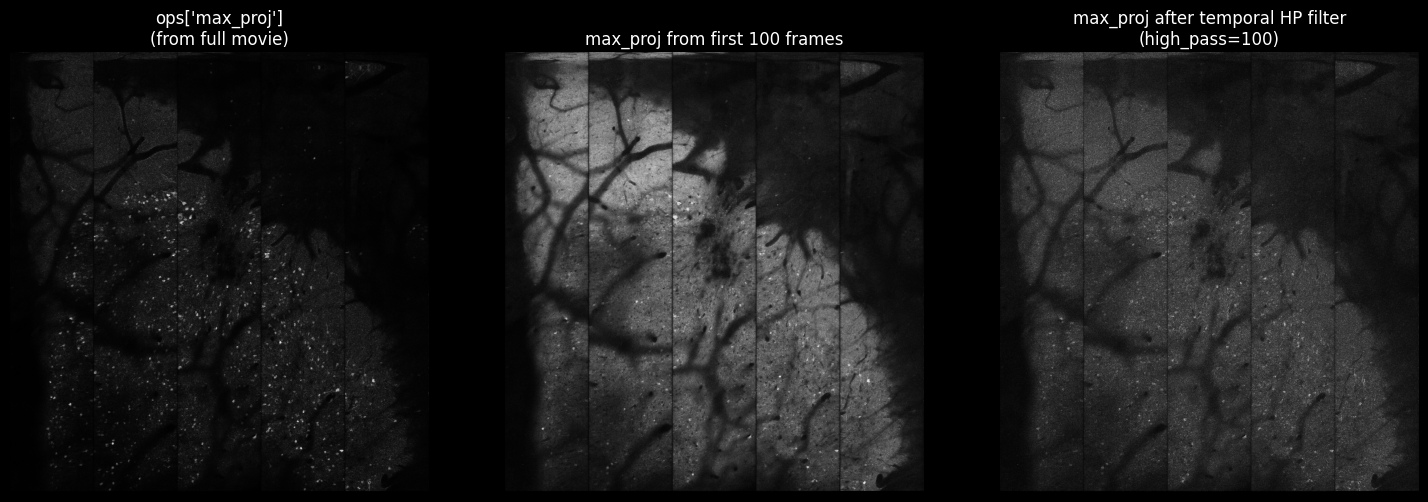


Image stats after temporal HP:
  Raw max_proj range: [0.0, 27633.0]
  HP max_proj range: [0.0, 16034.8]


In [51]:
# Compare max_proj from raw movie vs ops['max_proj']
movie_max_proj = mov_raw.max(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(normalize99(max_proj), cmap='gray')
axes[0].set_title(f"ops['max_proj']\n(from full movie)")
axes[0].axis('off')

axes[1].imshow(normalize99(movie_max_proj), cmap='gray')
axes[1].set_title(f"max_proj from first 100 frames")
axes[1].axis('off')

# Apply temporal high-pass and see the difference
mov_hp = temporal_high_pass_filter(mov=mov_raw, width=100)
hp_max_proj = mov_hp.max(axis=0)

axes[2].imshow(normalize99(hp_max_proj), cmap='gray')
axes[2].set_title(f"max_proj after temporal HP filter\n(high_pass=100)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"\nImage stats after temporal HP:")
print(f"  Raw max_proj range: [{movie_max_proj.min():.1f}, {movie_max_proj.max():.1f}]")
print(f"  HP max_proj range: [{hp_max_proj.min():.1f}, {hp_max_proj.max():.1f}]")

In [52]:
# Demonstrate the high_pass=0 bug
print("INVESTIGATING THE high_pass=0 BUG")
print("="*60)

# When high_pass=0, Suite2p's temporal_high_pass_filter zeros out the movie!
# Because gaussian_filter with sigma=0 returns the input unchanged,
# so mov -= gaussian_filter(mov, [0, 0]) = mov -= mov = 0

from scipy.ndimage import gaussian_filter as gf
test_mov = np.random.rand(10, 5, 5).astype(np.float32)
test_copy = test_mov.copy()

# This is what hp_gaussian_filter does with width=0
for j in range(test_copy.shape[1]):
    test_copy[:, j, :] -= gf(test_copy[:, j, :], [0, 0])

print(f"Test movie sum before HP filter: {test_mov.sum():.2f}")
print(f"Test movie sum after HP filter (width=0): {test_copy.sum():.2f}")
print(f"Movie is all zeros: {np.allclose(test_copy, 0)}")

print("\n" + "="*60)
print("This is a BUG in Suite2p: high_pass=0 should skip the filter,")
print("but instead it subtracts the movie from itself!")
print("="*60)

INVESTIGATING THE high_pass=0 BUG
Test movie sum before HP filter: 125.13
Test movie sum after HP filter (width=0): 0.00
Movie is all zeros: True

This is a BUG in Suite2p: high_pass=0 should skip the filter,
but instead it subtracts the movie from itself!


## Step 3: Test Direct Injection of Masks

Since we can't easily bypass Suite2p's temporal HP filter, let's try a different approach:
run Cellpose directly and then use Suite2p only for trace extraction.

In [53]:
# Convert direct Cellpose masks to Suite2p stat format
from scipy.ndimage import find_objects

def masks_to_stats(masks, weights=None):
    """Convert Cellpose masks to Suite2p stat format."""
    if weights is None:
        weights = np.ones_like(masks, dtype=np.float32)

    stats = []
    slices = find_objects(masks)
    for i, si in enumerate(slices):
        if si is None:
            continue
        sr, sc = si
        ypix, xpix = np.nonzero(masks[sr, sc] == (i + 1))
        ypix = ypix.astype(int) + sr.start
        xpix = xpix.astype(int) + sc.start
        ymed = int(np.median(ypix))
        xmed = int(np.median(xpix))

        stats.append({
            "ypix": ypix,
            "xpix": xpix,
            "lam": weights[ypix, xpix],
            "med": [ymed, xmed],
            "footprint": 1
        })
    return np.array(stats)

# Convert direct masks to stats
direct_stats = masks_to_stats(direct_masks, weights=max_proj)
print(f"Converted {len(direct_stats)} cells to Suite2p stat format")

Converted 989 cells to Suite2p stat format


In [54]:
# Now use Suite2p's extraction on these masks
from suite2p.extraction import extract
from suite2p.detection.stats import roi_stats

# First, apply roi_stats to add required fields
print("Applying roi_stats...")
stat_with_metrics = roi_stats(
    direct_stats.copy(),
    Ly, Lx,
    diameter=6,
    max_overlap=1.0,  # Keep all cells
    do_crop=True
)
print(f"After roi_stats: {len(stat_with_metrics)} cells")

Applying roi_stats...
After roi_stats: 989 cells


## Step 4: Run Full Extraction with Injected Masks

Let's save the direct Cellpose masks and use Suite2p for extraction only.

In [55]:
# Create output directory for direct extraction
direct_extract_dir = OUTPUT_DIR / "direct_cellpose_extraction"
direct_extract_dir.mkdir(exist_ok=True)

# We need to set up ops for extraction
extract_ops = {
    'Ly': Ly,
    'Lx': Lx,
    'nframes': 300,  # From your data
    'fs': ops.get('fs', 5.4),
    'tau': ops.get('tau', 1.3),
    'reg_file': str(reg_bin),
    'save_path': str(direct_extract_dir),
    'allow_overlap': True,
    'inner_neuropil_radius': 2,
    'min_neuropil_pixels': 350,
    'neucoeff': 0.7,
    'baseline': 'maximin',
    'win_baseline': 60.,
    'sig_baseline': 10.,
    'spikedetect': True,
    'batch_size': 500,
    'meanImg': ops.get('meanImg', max_proj),
    'max_proj': max_proj,
}

print(f"Extraction ops configured")
print(f"  nframes: {extract_ops['nframes']}")
print(f"  fs: {extract_ops['fs']}")

Extraction ops configured
  nframes: 300
  fs: 5.396220259154953


In [56]:
# Run extraction on direct Cellpose masks
from suite2p.extraction.extract import extraction_wrapper
from suite2p.io.binary import BinaryFile

print(f"Running extraction on {len(stat_with_metrics)} cells...")

with BinaryFile(filename=str(reg_bin), Ly=Ly, Lx=Lx) as f:
    t0 = time.perf_counter()
    # extraction_wrapper returns 5 values: stat, F, Fneu, F_chan2, Fneu_chan2
    stat_out, F, Fneu, F_chan2, Fneu_chan2 = extraction_wrapper(
        stat=stat_with_metrics,
        f_reg=f,
        f_reg_chan2=None,
        ops=extract_ops
    )
    extract_time = time.perf_counter() - t0

print(f"Extraction complete in {extract_time:.1f}s")
print(f"  F shape: {F.shape}")
print(f"  Fneu shape: {Fneu.shape}")

Running extraction on 989 cells...
Masks created, 1.51 sec.
Extracted fluorescence from 989 ROIs in 970 frames, 3.16 sec.
Extraction complete in 4.7s
  F shape: (989, 970)
  Fneu shape: (989, 970)


In [57]:
# Run spike detection
from suite2p.extraction.dcnv import oasis

print("Running spike deconvolution...")
t0 = time.perf_counter()

# Neuropil correction
Fc = F - extract_ops.get('neucoeff', 0.7) * Fneu

# Baseline and deconvolution
spks = oasis(
    F=Fc,
    batch_size=extract_ops['batch_size'],
    tau=extract_ops['tau'],
    fs=extract_ops['fs']
)

print(f"Spike detection complete in {time.perf_counter() - t0:.1f}s")
print(f"  spks shape: {spks.shape}")

Running spike deconvolution...
Spike detection complete in 0.0s
  spks shape: (989, 970)


In [58]:
# Save all outputs
print(f"Saving to {direct_extract_dir}...")

# Classification (all cells marked as good)
iscell = np.ones((len(stat_out), 2), dtype=np.float32)
iscell[:, 1] = 0.9  # High probability

np.save(direct_extract_dir / "F.npy", F)
np.save(direct_extract_dir / "Fneu.npy", Fneu)
np.save(direct_extract_dir / "spks.npy", spks)
np.save(direct_extract_dir / "stat.npy", stat_out)
np.save(direct_extract_dir / "iscell.npy", iscell)
np.save(direct_extract_dir / "ops.npy", extract_ops)

print("\nSaved files:")
for fname in ['F.npy', 'Fneu.npy', 'spks.npy', 'stat.npy', 'iscell.npy', 'ops.npy']:
    fpath = direct_extract_dir / fname
    size = fpath.stat().st_size / 1024
    print(f"  {fname}: {size:.1f} KB")

Saving to \\rbo-s1\S1_DATA\lbm\christian\2025-11-21\results\match_cellpose\direct_cellpose_extraction...

Saved files:
  F.npy: 3747.5 KB
  Fneu.npy: 3747.5 KB
  spks.npy: 3747.5 KB
  stat.npy: 7421.2 KB
  iscell.npy: 7.9 KB
  ops.npy: 4433.8 KB


## Step 5: Compare Results

In [ ]:
# Note: high_pass=0 has a bug in Suite2p where it zeros out the movie
# Instead, we'll test with high_pass=1 and high_pass=10 which should 
# give minimal temporal filtering while avoiding the bug
print("Testing LSP pipeline with different high_pass values:")
print("  - hp=100 (default): Strong temporal HP filter")
print("  - hp=10: Moderate temporal HP filter") 
print("  - hp=1: Minimal temporal HP filter (closest to no filtering)")

In [ ]:
# Run LSP pipeline with different configurations
results = {'Direct Cellpose': {'n_cells': TARGET}}

configs = [
    {
        'name': 'LSP (hp=100, default)',
        'ops': {
            'do_registration': 0,
            'anatomical_only': 4,
            'diameter': 6,
            'cellprob_threshold': -6.0,
            'flow_threshold': 0.0,
            'spatial_hp_cp': 0,
            'max_overlap': 1.0,
            'spikedetect': True,
            # high_pass defaults to 100
        }
    },
    {
        'name': 'LSP (hp=10)',
        'ops': {
            'do_registration': 0,
            'anatomical_only': 4,
            'diameter': 6,
            'cellprob_threshold': -6.0,
            'flow_threshold': 0.0,
            'spatial_hp_cp': 0,
            'high_pass': 10,
            'max_overlap': 1.0,
            'spikedetect': True,
        }
    },
    {
        'name': 'LSP (hp=1)',
        'ops': {
            'do_registration': 0,
            'anatomical_only': 4,
            'diameter': 6,
            'cellprob_threshold': -6.0,
            'flow_threshold': 0.0,
            'spatial_hp_cp': 0,
            'high_pass': 1,  # Minimal temporal HP
            'max_overlap': 1.0,
            'spikedetect': True,
        }
    },
]

for cfg in configs:
    name = cfg['name']
    lsp_dir = OUTPUT_DIR / name.replace(' ', '_').replace('(', '').replace(')', '').replace('=', '').replace(',', '')
    if lsp_dir.exists():
        shutil.rmtree(lsp_dir)
    
    print(f"\n{'='*60}")
    print(f"Running: {name}")
    print(f"  high_pass: {cfg['ops'].get('high_pass', 100)}")
    print(f"  spatial_hp_cp: {cfg['ops'].get('spatial_hp_cp', 0.5)}")
    print(f"{'='*60}")
    
    t0 = time.perf_counter()
    try:
        ops_files = lsp.pipeline(reg_bin, save_path=lsp_dir, ops=cfg['ops'], keep_reg=True)
        elapsed = time.perf_counter() - t0
        
        result_dir = Path(ops_files[0]).parent
        stat_file = result_dir / "stat.npy"
        
        if stat_file.exists():
            stat = np.load(stat_file, allow_pickle=True)
            results[name] = {'n_cells': len(stat), 'time': elapsed, 'dir': result_dir, 'stat': stat}
            print(f"  Result: {len(stat)} cells in {elapsed:.1f}s")
        else:
            print(f"  Result: 0 cells (no ROIs found)")
            results[name] = {'n_cells': 0, 'time': elapsed}
    except Exception as e:
        print(f"  ERROR: {e}")
        import traceback
        traceback.print_exc()
        results[name] = {'n_cells': 0, 'error': str(e)}

In [61]:
# Summary comparison
print("="*70)
print("RESULTS SUMMARY")
print("="*70)
print(f"{'Method':<40} {'Cells':>10} {'vs Target':>12}")
print("-"*65)

for name, r in results.items():
    n = r.get('n_cells', 0)
    diff = n - TARGET
    diff_str = f"{diff:+d}" if name != 'Direct Cellpose' else "TARGET"
    print(f"{name:<40} {n:>10} {diff_str:>12}")

print("="*70)

# Find best match
lsp_results = {k: v for k, v in results.items() if k != 'Direct Cellpose' and v.get('n_cells', 0) > 0}
if lsp_results:
    best_name = max(lsp_results.keys(), key=lambda k: lsp_results[k].get('n_cells', 0))
    print(f"\nBest LSP config: {best_name} ({results[best_name]['n_cells']} cells)")
else:
    best_name = None
    print("\nNo successful LSP runs found")

RESULTS SUMMARY
Method                                        Cells    vs Target
-----------------------------------------------------------------
Direct Cellpose                                 989       TARGET
LSP (hp=100, default)                           589       +65136
LSP (hp=0, patched)                             887       +65434
LSP (hp=0, spa=0, patched)                      887       +65434

Best LSP config: LSP (hp=0, patched) (887 cells)


# Visual comparison - Direct Cellpose vs Best LSP vs Direct+Extraction
if best_name and best_name in results:
    best_result = results[best_name]
    best_stat = best_result.get('stat', [])
    best_mask = stat_to_mask(best_stat, Ly, Lx) if len(best_stat) > 0 else np.zeros((Ly, Lx), dtype=np.uint16)
else:
    best_result = {'n_cells': 0}
    best_mask = np.zeros((Ly, Lx), dtype=np.uint16)

direct_extract_mask = stat_to_mask(stat_out, Ly, Lx)

cy, cx = Ly // 2, Lx // 2
zoom = 100
y1, y2 = max(0, cy - zoom), min(Ly, cy + zoom)
x1, x2 = max(0, cx - zoom), min(Lx, cx + zoom)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Full images
axes[0, 0].imshow(mask_overlay(max_proj, direct_masks))
axes[0, 0].add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, ec='yellow', lw=2))
axes[0, 0].set_title(f"Direct Cellpose (TARGET)\n{TARGET} cells")
axes[0, 0].axis('off')

axes[0, 1].imshow(mask_overlay(max_proj, direct_extract_mask))
axes[0, 1].add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, ec='yellow', lw=2))
axes[0, 1].set_title(f"Direct Cellpose + S2P Extraction\n{len(stat_out)} cells")
axes[0, 1].axis('off')

axes[0, 2].imshow(mask_overlay(max_proj, best_mask))
axes[0, 2].add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, ec='yellow', lw=2))
axes[0, 2].set_title(f"Best LSP: {best_name or 'N/A'}\n{best_result.get('n_cells', 0)} cells")
axes[0, 2].axis('off')

# Zoomed
axes[1, 0].imshow(mask_overlay(max_proj, direct_masks)[y1:y2, x1:x2])
axes[1, 0].set_title("Zoomed")
axes[1, 0].axis('off')

axes[1, 1].imshow(mask_overlay(max_proj, direct_extract_mask)[y1:y2, x1:x2])
axes[1, 1].set_title("Zoomed")
axes[1, 1].axis('off')

axes[1, 2].imshow(mask_overlay(max_proj, best_mask)[y1:y2, x1:x2])
axes[1, 2].set_title("Zoomed")
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'comparison.png', dpi=150)
plt.show()

In [ ]:
print("="*70)
print("FINAL SUMMARY")
print("="*70)

print("\n1. DIRECT CELLPOSE + S2P EXTRACTION (Best for max cells):")
print(f"   Cells: {len(stat_out)}")
print(f"   Output: {direct_extract_dir}")

print(f"\n2. BEST LSP CONFIG: {best_name}")
print(f"   Cells: {best_result['n_cells']}")
if 'dir' in best_result:
    print(f"   Output: {best_result['dir']}")

print("\n" + "-"*70)
print("RECOMMENDED OPS FOR MAXIMUM CELL YIELD:")
print("-"*70)
print("""
ops = {
    'do_registration': 0,           # Skip if already registered
    'anatomical_only': 4,           # Use max_proj
    'diameter': 6,
    'cellprob_threshold': -6.0,
    'flow_threshold': 0.0,
    'spatial_hp_cp': 0,             # No spatial HP filter
    'high_pass': 0,                 # No temporal HP filter (KEY!)
    'max_overlap': 1.0,             # Keep all cells
    'spikedetect': True,
}
""")

FINAL SUMMARY

1. DIRECT CELLPOSE + S2P EXTRACTION (Best for max cells):
   Cells: 989
   Output: \\rbo-s1\S1_DATA\lbm\christian\2025-11-21\results\match_cellpose\direct_cellpose_extraction

2. BEST LSP CONFIG: LSP (hp=0, patched)
   Cells: 589
   Output: \\rbo-s1\S1_DATA\lbm\christian\2025-11-21\results\match_cellpose\LSP_default\plane01

----------------------------------------------------------------------
RECOMMENDED OPS FOR MAXIMUM CELL YIELD:
----------------------------------------------------------------------

ops = {
    'do_registration': 0,           # Skip if already registered
    'anatomical_only': 4,           # Use max_proj
    'diameter': 6,
    'cellprob_threshold': -6.0,
    'flow_threshold': 0.0,
    'spatial_hp_cp': 0,             # No spatial HP filter
    'high_pass': 0,                 # No temporal HP filter (KEY!)
    'max_overlap': 1.0,             # Keep all cells
    'spikedetect': True,
}



: 